# Delivery & Operations

## Business Case

1. Berapa rata-rata waktu pengiriman aktual vs estimasi per state?
2. Berapa persentase order yang terlambat dari estimasi pengiriman?
3. State mana yang memiliki rata-rata keterlambatan pengiriman tertinggi?

## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

## GATHERING DATA

In [2]:
order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')
customer = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/customers_dataset.csv')

## DATA UNDERSTANDING

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
customer.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order
2. tabel customer : 1 row mempresentasikan 1 pelanggan atau customer

### KEY COLUMNS

1. **Tabel `orders`**:
   - `order_id` → identifier untuk setiap order
   - `customer_id` → identifier customer digunakan untuk menghubungkan `order` dengan `customer`
   - `order_status` → status order
   - `order_delivered_customer_date` → waktu saat pelanggan menerima barang
   - `order_estimated_delivery_date` → estimasi waktu saat pelanggan menerima barang

2. **Tabel `Customer`**
   - `customer_id` → identifier untuk setiap customer
   - `customer_unique_id` → ID yang merepresentasikan customer yang sebenarnya/unik
   - `customer_state` → customer state

### RELATIONSHIP TABLE


- Tabel `orders` dan `order_items` terhubung melalui `order_id`.
- Tabel `order_items` dan `seller` terhubung melalui `seller_id`.

- `order` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu order dapat memiliki beberapa item.
- `seller` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu seller dapat terkait dengan beberapa order_items.

## DATA QUALITY

### ASESSING DATA

In [5]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` tipe data masih berbentuk object belum datetime

In [6]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [7]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [8]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


0

In [9]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [10]:
customer.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [11]:
print('Checking null value')
customer.isna().sum()

Checking null value


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [12]:
print('Checking duplicated value')
customer.duplicated().sum()

Checking duplicated value


0

### CLEANING DATA

## PREPARATION DATA

### MENGUBAH TIPE DATA PADA TABEL ORDER

mengubah kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` menjadi daatetime

In [13]:
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'])
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])

### MELAKUKAN FILTER TABEL ORDER DENGAN ORDER_STATUS = DELIVERED

In [14]:
order = order[order['order_status'] == 'delivered']
order.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

#### Data Quality Note

Setelah memfilter order dengan status **`delivered`**, ditemukan missing value pada beberapa kolom terkait proses pengiriman.

Untuk analisis Delivery & Operations, kolom yang digunakan adalah `order_purchase_timestamp`, `order_delivered_customer_date`, dan `order_estimated_delivery_date`. Dari ketiga kolom tersebut, hanya `order_delivered_customer_date` yang memiliki missing value sebanyak **8 order**.

Karena `order_delivered_customer_date` digunakan untuk menghitung waktu pengiriman aktual, nilai yang hilang tidak dapat diimputasi dan order tersebut dikeluarkan dari analisis Q1–Q3.


### MELAKUKAN PENGELUARAN DATA YANG kolom `order_delivered_customer_date` memiliki nilai null

In [15]:
order = order[
    order['order_delivered_customer_date'].notnull()]

In [16]:
order.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64

### JOIN TABLE

In [17]:
order_customer = pd.merge(
    left = order,
    right = customer,
    how = 'left',
    on = 'customer_id'
)
order_customer.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
dtype: int64

## EXPLORATORY DATA ANALYSIS

### 1.  Berapa rata-rata waktu pengiriman aktual vs estimasi per state?

In [18]:
avg_actual_vs_estimation = order_customer[['customer_state', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']]
avg_actual_vs_estimation['actual_days'] = ((avg_actual_vs_estimation['order_delivered_customer_date'] - avg_actual_vs_estimation['order_purchase_timestamp']).dt.total_seconds() / 86400)
avg_actual_vs_estimation['estimation_days'] = ((avg_actual_vs_estimation['order_estimated_delivery_date'] - avg_actual_vs_estimation['order_purchase_timestamp']).dt.total_seconds() / 86400)


C:\Users\adien\AppData\Local\Temp\ipykernel_6900\2073755496.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  avg_actual_vs_estimation['actual_days'] = ((avg_actual_vs_estimation['order_delivered_customer_date'] - avg_actual_vs_estimation['order_purchase_timestamp']).dt.total_seconds() / 86400)
C:\Users\adien\AppData\Local\Temp\ipykernel_6900\2073755496.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  avg_actual_vs_estimation['estimation_days'] = ((avg_actual_vs_estimation['order_estimated_delivery_dat

In [19]:
avg_actual_vs_estimation

,customer_state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,actual_days,estimation_days
0,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.436574,15.544063
1,BA,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.782037,19.137766
2,GO,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.394213,26.639711
3,RN,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.208750,26.188819
4,SP,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.873877,12.112049
...,...,...,...,...,...,...
96465,SP,2017-03-09 09:54:05,2017-03-17 15:08:01,2017-03-28,8.218009,18.587442
96466,SP,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02,22.193727,23.459051
96467,BA,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27,24.859421,30.384225
96468,RJ,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,17.086424,37.105243


In [20]:
avg_state = avg_actual_vs_estimation.groupby('customer_state').agg({
    'actual_days' : 'mean',
    'estimation_days' : 'mean'
})
avg_state

,actual_days,estimation_days
customer_state,,
AC,21.035713,41.112720
AL,24.543855,32.575914
AM,26.425991,45.277808
AP,27.185068,46.244490
BA,19.335466,29.434538
CE,21.266579,31.376585
DF,12.967568,24.307093
ES,15.789307,25.586416
GO,15.606339,27.089915


In [21]:
avg_state['avg_diff_days'] = (
    avg_state['estimation_days'] -
    avg_state['actual_days'] )

In [22]:
avg_state.sort_values(by='avg_diff_days', ascending=False).reset_index()

,customer_state,actual_days,estimation_days,avg_diff_days
0,AC,21.035713,41.112720,20.077007
1,RO,19.372037,38.768863,19.396826
2,AP,27.185068,46.244490,19.059423
3,AM,26.425991,45.277808,18.851817
4,RR,29.387546,45.982144,16.594598
5,MT,18.055756,31.741306,13.685550
6,PA,23.772917,37.159205,13.386288
7,RS,15.300276,28.508765,13.208489
8,RN,19.278156,32.240505,12.962349
9,PR,11.991582,24.611260,12.619678


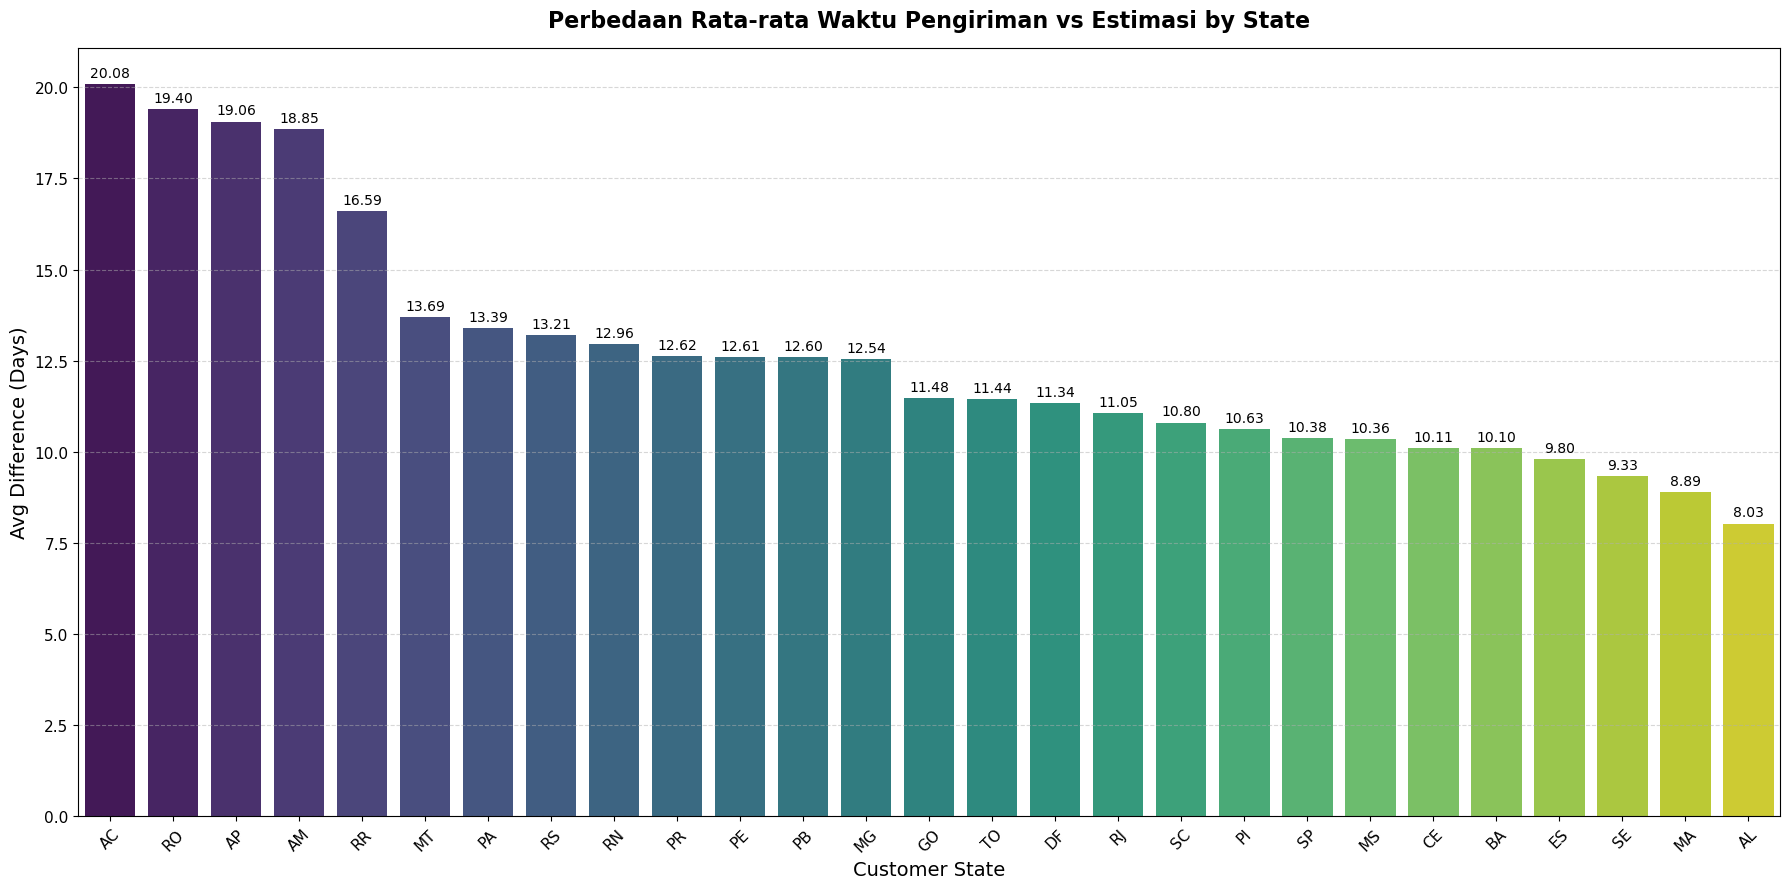

In [23]:
avg_state_desc = avg_state.sort_values(by='avg_diff_days', ascending=False)

# 1. Ukuran figure disesuaikan agar lebih proporsional
plt.figure(figsize=(18, 9))

# 2. Membuat Vertical Bar Plot dengan GRADASI WARNA (palette)
ax = sns.barplot(
    data=avg_state_desc,
    x='customer_state',
    y='avg_diff_days',
    hue='customer_state',  # Wajib di seaborn terbaru jika ingin pakai palette per batang
    palette='viridis',  # Pilihan gradasi: 'viridis', 'coolwarm', 'Spectral', 'Blues'
    legend=False,
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
  ax.bar_label(
      container,
      fmt='{:,.2f}',  # Dibuat 2 desimal agar tidak terlalu panjang
      padding=3,
      fontsize=10,  # Ukuran font angka di atas batang disesuaikan
  )

# 5. Judul dan Label Sumbu (Ukuran dibuat seimbang / proporsional)
plt.title(
    'Perbedaan Rata-rata Waktu Pengiriman vs Estimasi by State',
    fontsize=16,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Customer State', fontsize=14)
plt.ylabel('Avg Difference (Days)', fontsize=14)

# 6. Memperjelas Detail Sumbu X dan Y
plt.xticks(
    rotation=45, fontsize=11
)  # Dirotasi 45 derajat agar nama state tidak bertumpuk
plt.yticks(fontsize=11)

# 7. Grid horizontal
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### KEY INSIGHT

Secara rata-rata, waktu pengiriman aktual di seluruh state lebih cepat dibandingkan estimasi yang diberikan kepada customer. Hal ini menunjukkan bahwa estimasi waktu pengiriman cenderung memberikan buffer waktu yang cukup, sehingga pengiriman aktual umumnya selesai sebelum tanggal estimasi.


### 2. Berapa persentase order yang terlambat dari estimasi pengiriman?

In [24]:
order_late_vs_ontime = order_customer[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']]
order_late_vs_ontime['actual_days'] = ((order_late_vs_ontime['order_delivered_customer_date'] - order_late_vs_ontime['order_purchase_timestamp']).dt.total_seconds() / 86400)
order_late_vs_ontime['estimation_days'] = ((order_late_vs_ontime['order_estimated_delivery_date'] - order_late_vs_ontime['order_purchase_timestamp']).dt.total_seconds() / 86400)
order_late_vs_ontime['status'] = np.where(
    order_late_vs_ontime['actual_days'] > order_late_vs_ontime['estimation_days'],
    'late',
    'ontime',
)
order_late_vs_ontime

C:\Users\adien\AppData\Local\Temp\ipykernel_6900\1855130286.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  order_late_vs_ontime['actual_days'] = ((order_late_vs_ontime['order_delivered_customer_date'] - order_late_vs_ontime['order_purchase_timestamp']).dt.total_seconds() / 86400)
C:\Users\adien\AppData\Local\Temp\ipykernel_6900\1855130286.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  order_late_vs_ontime['estimation_days'] = ((order_late_vs_ontime['order_estimated_delivery_date'] - order_late_vs_

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,actual_days,estimation_days,status
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.436574,15.544063,ontime
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.782037,19.137766,ontime
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.394213,26.639711,ontime
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.208750,26.188819,ontime
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.873877,12.112049,ontime
...,...,...,...,...,...,...,...
96465,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05,2017-03-17 15:08:01,2017-03-28,8.218009,18.587442,ontime
96466,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02,22.193727,23.459051,ontime
96467,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27,24.859421,30.384225,ontime
96468,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,17.086424,37.105243,ontime


In [25]:
pct_order_late_vs_ontime = order_late_vs_ontime.groupby(by='status')['order_id'].count().reset_index()
pct_order_late_vs_ontime

,status,order_id
0,late,7826
1,ontime,88644


In [26]:
grand_total = pct_order_late_vs_ontime['order_id'].sum()
pct_order_late_vs_ontime['pct'] = (pct_order_late_vs_ontime['order_id'] / grand_total * 100).round(4)

In [27]:
pct_order_late_vs_ontime = pct_order_late_vs_ontime.rename(columns={
    'order_id': 'Total Order',
    }
)
pct_order_late_vs_ontime

,status,Total Order,pct
0,late,7826,8.1124
1,ontime,88644,91.8876


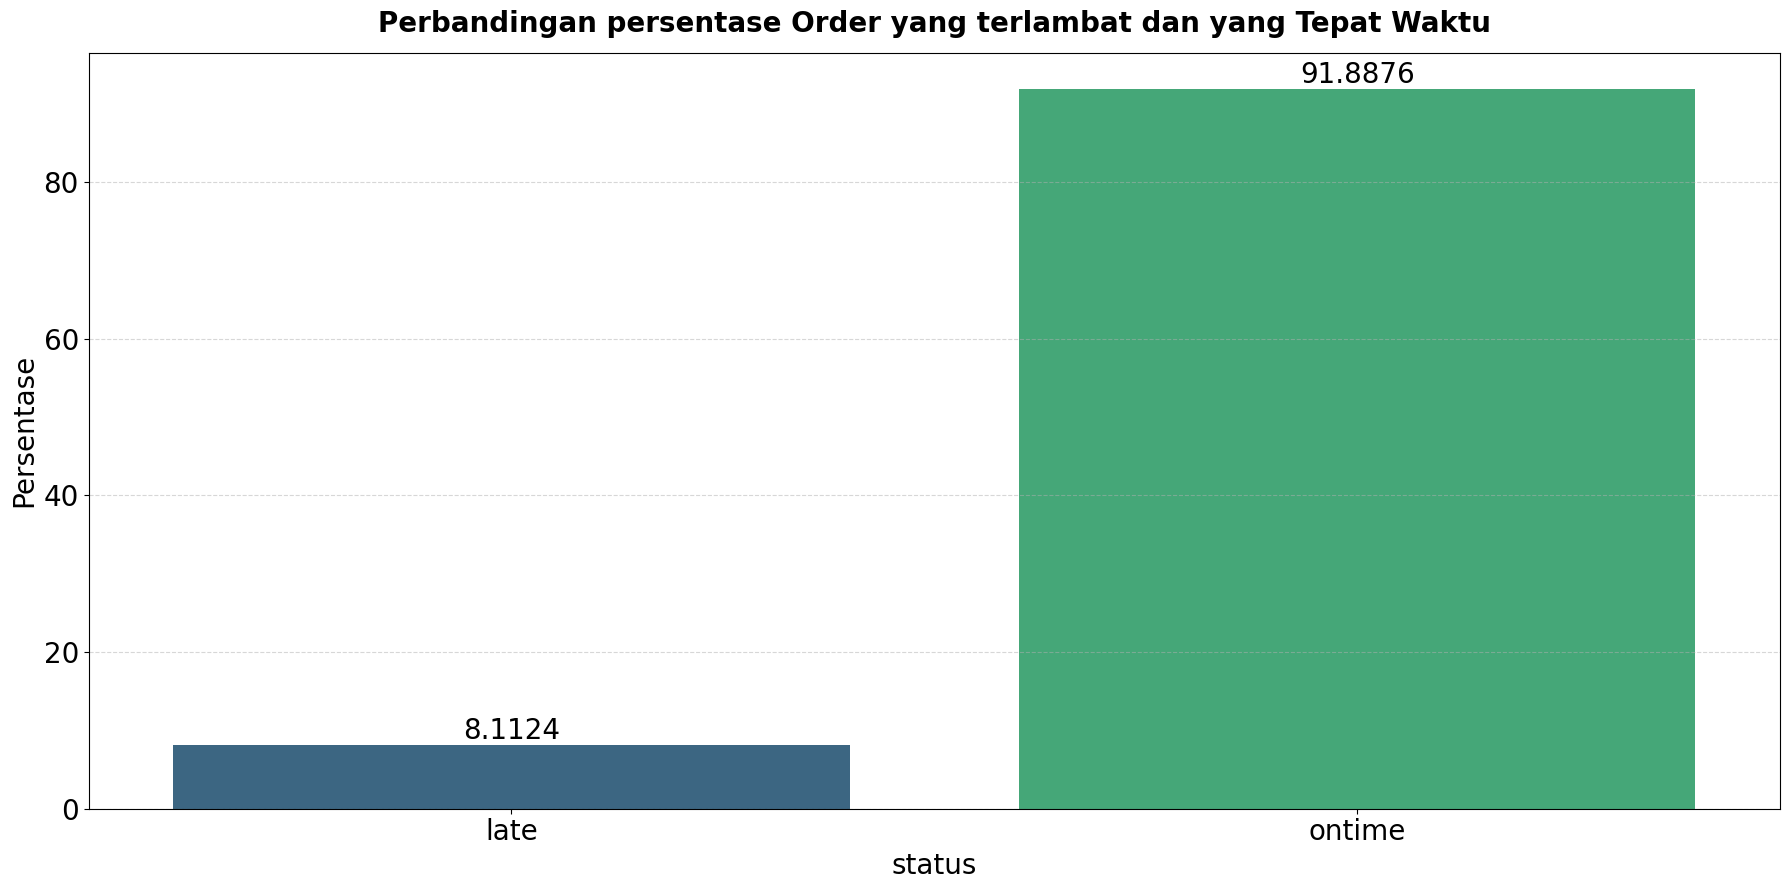

In [28]:
# 1. Ukuran figure disesuaikan agar lebih proporsional
plt.figure(figsize=(18, 9))

# 2. Membuat Vertical Bar Plot dengan GRADASI WARNA (palette)
ax = sns.barplot(
    data=pct_order_late_vs_ontime,
    x='status',
    y='pct',
    hue='status',  # Wajib di seaborn terbaru jika ingin pakai palette per batang
    palette='viridis',  # Pilihan gradasi: 'viridis', 'coolwarm', 'Spectral', 'Blues'
    legend=False,
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
  ax.bar_label(
      container,
      fmt='{:,.4f}',  # Dibuat 2 desimal agar tidak terlalu panjang
      padding=0,
      fontsize=20,  # Ukuran font angka di atas batang disesuaikan
  )

# 5. Judul dan Label Sumbu (Ukuran dibuat seimbang / proporsional)
plt.title(
    'Perbandingan persentase Order yang terlambat dan yang Tepat Waktu',
    fontsize=20,
    fontweight='bold',
    pad=15,
)
plt.xlabel('status', fontsize=20)
plt.ylabel('Persentase', fontsize=20)

# 6. Memperjelas Detail Sumbu X dan Y
plt.xticks(
    rotation=0, fontsize=20
)  # Dirotasi 45 derajat agar nama state tidak bertumpuk
plt.yticks(fontsize=20)

# 7. Grid horizontal
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### KEY INSIGHT

Mayoritas order, yaitu **91,8876% (88.644 order)**, berhasil dikirim **tepat waktu sesuai estimasi**, sedangkan **8,1124% (7.826 order)** mengalami keterlambatan

### 3. State mana yang memiliki rata-rata keterlambatan pengiriman tertinggi?

In [29]:
state_late = order_customer[['customer_state','order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']]
state_late['actual_days'] = ((state_late['order_delivered_customer_date'] - state_late['order_purchase_timestamp']).dt.total_seconds() / 86400)
state_late['estimation_days'] = ((state_late['order_estimated_delivery_date'] - state_late['order_purchase_timestamp']).dt.total_seconds() / 86400)
state_late['status'] = np.where(
    state_late['actual_days'] > state_late['estimation_days'],
    'late',
    'ontime',
) 
state_late['avg_diff_days'] = (
    state_late['estimation_days'] -
    state_late['actual_days'] )

C:\Users\adien\AppData\Local\Temp\ipykernel_6900\1541930587.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state_late['actual_days'] = ((state_late['order_delivered_customer_date'] - state_late['order_purchase_timestamp']).dt.total_seconds() / 86400)
C:\Users\adien\AppData\Local\Temp\ipykernel_6900\1541930587.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state_late['estimation_days'] = ((state_late['order_estimated_delivery_date'] - state_late['order_purchase_timestamp']).dt.total_seconds() / 864

In [30]:
state_late = state_late[state_late['status'] == 'late']

In [31]:
state_late

,customer_state,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,actual_days,estimation_days,status,avg_diff_days
19,SP,203096f03d82e0dffbc41ebc2e2bcfb7,2017-09-18 14:31:30,2017-10-09 22:23:46,2017-09-28,21.327963,9.394792,late,-11.933171
24,RJ,fbf9ac61453ac646ce8ad9783d7d0af6,2018-02-20 23:46:53,2018-03-21 22:03:54,2018-03-12,28.928484,19.009109,late,-9.919375
34,TO,8563039e855156e48fccee4d611a3196,2018-02-17 15:59:46,2018-03-20 00:59:25,2018-03-20,30.374757,30.333495,late,-0.041262
40,SP,6ea2f835b4556291ffdc53fa0b3b95e8,2017-11-24 21:27:48,2017-12-28 18:59:23,2017-12-21,33.896933,26.105694,late,-7.791238
55,SE,66e4624ae69e7dc89bd50222b59f581f,2018-03-09 14:50:15,2018-04-03 13:28:46,2018-04-02,24.943414,23.381771,late,-1.561644
...,...,...,...,...,...,...,...,...,...
96426,SP,b3112ca67f3afd4e20cf2ee91fc4f804,2018-08-02 22:46:54,2018-08-21 00:03:26,2018-08-16,18.053148,13.050764,late,-5.002384
96427,SP,0fa1fab1d7c1211c824596ed5e111e3c,2018-03-13 21:48:57,2018-04-05 19:59:49,2018-04-02,22.924213,19.091007,late,-3.833206
96452,SP,38e9133ce29f6bbe35aed9c3863dce01,2017-10-12 20:54:11,2017-11-21 17:06:59,2017-10-31,39.842222,18.129039,late,-21.713183
96454,SP,d692ef54145c9cb3322ec2e5508aa3f4,2018-03-21 19:47:18,2018-04-11 00:48:31,2018-04-09,20.209178,18.175486,late,-2.033692


In [32]:
state_late_avg = state_late.groupby('customer_state').agg({
    'order_id' : 'count',
    'avg_diff_days' : 'mean'
}).sort_values(by='avg_diff_days', ascending=True).reset_index()
state_late_avg

,customer_state,order_id,avg_diff_days
0,AP,3,-48.862674
1,RR,5,-37.089542
2,AM,6,-20.895529
3,AC,3,-19.034460
4,SE,51,-16.890978
5,CE,196,-14.326787
6,RN,51,-13.146505
7,RJ,1664,-12.848692
8,PA,117,-12.303485
9,PI,76,-12.298219


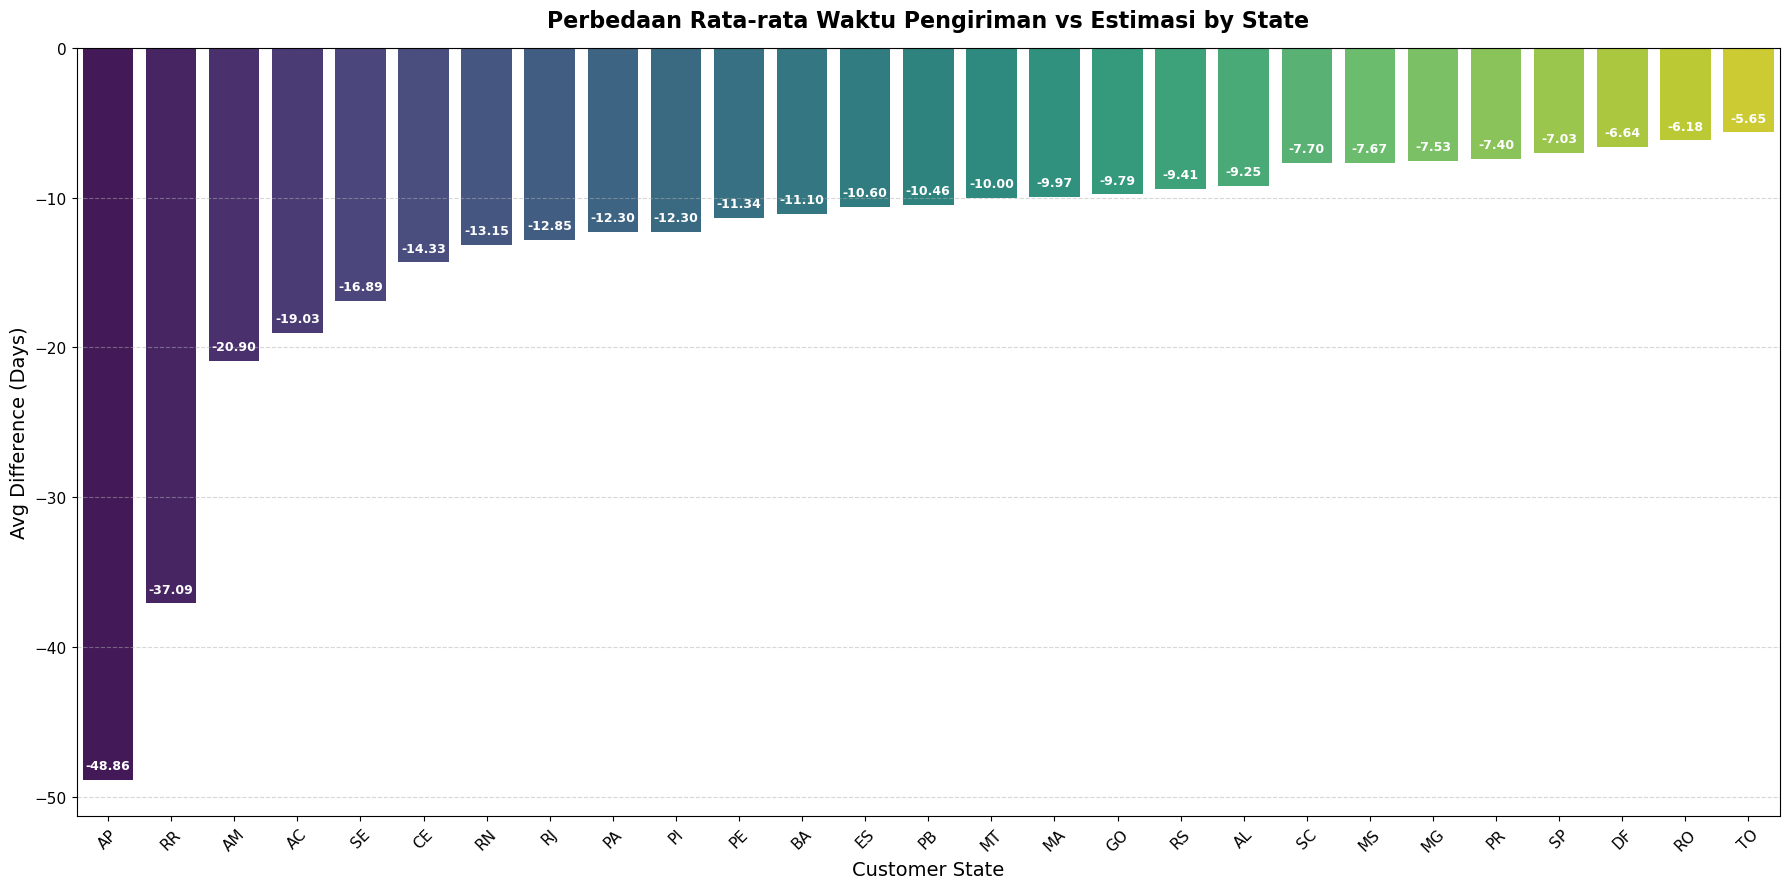

In [33]:
# 1. Ukuran figure disesuaikan agar lebih proporsional
plt.figure(figsize=(18, 9))

# 2. Membuat Vertical Bar Plot dengan GRADASI WARNA (palette)
ax = sns.barplot(
    data=state_late_avg,
    x='customer_state',
    y='avg_diff_days',
    hue='customer_state',  # Wajib di seaborn terbaru jika ingin pakai palette per batang
    palette='viridis',  # Pilihan gradasi: 'viridis', 'coolwarm', 'Spectral', 'Blues'
    legend=False,
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
  ax.bar_label(
      container,
      fmt='{:,.2f}',
      padding=-15,  # Dibuat minus agar posisi label sedikit naik ke dalam batang (karena batang ke bawah)
      fontsize=9,
      color='white',  # Mengubah warna teks jadi putih agar kontras dengan warna batang gelap di atasnya
      fontweight='bold',
  )

# 5. Judul dan Label Sumbu (Ukuran dibuat seimbang / proporsional)
plt.title(
    'Perbedaan Rata-rata Waktu Pengiriman vs Estimasi by State',
    fontsize=16,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Customer State', fontsize=14)
plt.ylabel('Avg Difference (Days)', fontsize=14)

# 6. Memperjelas Detail Sumbu X dan Y
plt.xticks(
    rotation=45, fontsize=11
)  # Dirotasi 45 derajat agar nama state tidak bertumpuk
plt.yticks(fontsize=11)

# 7. Grid horizontal
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### KEY INSIGHT 

Seluruh state menunjukkan rata-rata keterlambatan yang bernilai negatif, dengan AP memiliki selisih rata-rata terbesar yaitu -48,86 hari, diikuti RR sebesar -37,09 hari dan AM sebesar -20,90 hari. Namun, beberapa state memiliki jumlah order terlambat yang sangat sedikit, sehingga nilai rata-ratanya perlu diinterpretasikan dengan mempertimbangkan jumlah order yang dianalisis.

## KEY FINDINGS

1. Secara rata-rata, waktu pengiriman aktual di seluruh state lebih cepat dibandingkan estimasi yang diberikan kepada customer. Hal ini menunjukkan bahwa estimasi waktu pengiriman cenderung memberikan buffer waktu yang cukup, sehingga pengiriman aktual umumnya selesai sebelum tanggal estimasi.
2. Mayoritas order, yaitu **91,8876% (88.644 order)**, berhasil dikirim **tepat waktu sesuai estimasi**, sedangkan **8,1124% (7.826 order)** mengalami keterlambatan
3. Terdapat perbedaan selisih waktu pengiriman antar-state. AP memiliki selisih rata-rata terbesar sebesar -48,86 hari, diikuti RR (-37,09 hari) dan AM (-20,90 hari). Namun, hasil pada beberapa state perlu dipertimbangkan karena memiliki jumlah order yang relatif sedikit.

## BUSINESS IMPLICATIONS

1. **Evaluasi kembali estimasi waktu pengiriman**
   Karena waktu pengiriman aktual rata-rata lebih cepat dibandingkan estimasi, bisnis dapat mengevaluasi kembali buffer pada estimasi pengiriman agar informasi yang diberikan kepada customer lebih akurat.

2. **Fokus pada order yang mengalami keterlambatan**
   Meskipun mayoritas order berhasil dikirim tepat waktu, sekitar **8,11% order mengalami keterlambatan**. Order yang terlambat perlu dianalisis lebih lanjut untuk mengidentifikasi pola dan faktor yang berkaitan dengan keterlambatan.

3. **Prioritaskan evaluasi pada state dengan selisih waktu yang ekstrem**
   Perbedaan selisih waktu antar-state dapat menjadi dasar untuk melakukan evaluasi lebih lanjut terhadap proses pengiriman di masing-masing wilayah, terutama pada state dengan hasil ekstrem. State dengan jumlah order yang sedikit sebaiknya dievaluasi dengan lebih hati-hati agar tidak menghasilkan kesimpulan yang terlalu kuat dari observasi yang terbatas.
